In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0315_all_test.fits')

In [4]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())

Data loading and processing took 36.63 seconds.


In [32]:
# example_idx = np.random.choice(len(DP_SPECTRA.targetID))
# example_df = dps_df.iloc[example_idx]
example_id = 39627818262334340	
example_df = dps_df[dps_df['TARGETID'] == example_id].iloc[0]
example_idx = DP_SPECTRA.id2index(example_df['TARGETID'])
lam = desi_wavelength / (1 + example_df['Z'])
flux, ivar = DP_SPECTRA.flux[example_idx], DP_SPECTRA.ivar[example_idx]
sigma = 1/np.sqrt(np.abs(ivar))


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_35657/306793236.py:8: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [33]:
example_df

TARGETID        39627818262334340
RA                     198.874664
DEC                      1.349361
Z                        0.032428
LOGM                     8.390122
                      ...        
BPT_2COMP_L                   256
BPT_2COMP_R                   256
BPT_2COMP                     512
LOGSFR_1COMP            -5.406441
LOGSFR_2COMP            10.813166
Name: 53067, Length: 78, dtype: object

In [34]:
test_1comp = model_1comp[example_idx]
test_2comp_l = left_2comp[example_idx]
test_2comp_r = right_2comp[example_idx]
test_2comp = test_2comp_l + test_2comp_r

In [35]:
example_df[['OII3726_FLUX_1COMP', 'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP',
       'OIII4959_FLUX_1COMP', 'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP',]]

OII3726_FLUX_1COMP     0.002121
OII3729_FLUX_1COMP     0.002823
Hbeta_FLUX_1COMP       0.002097
OIII4959_FLUX_1COMP     0.00217
OIII5007_FLUX_1COMP    0.006574
NII6548_FLUX_1COMP     0.000203
Halpha_FLUX_1COMP      0.009049
NII6583_FLUX_1COMP     0.000623
Name: 53067, dtype: object

In [36]:
example_df[['OII3726_SNR', 'OII3729_SNR', 'Hbeta_SNR',
       'OIII4959_SNR', 'OIII5007_SNR', 'NII6548_SNR', 'Halpha_SNR',
       'NII6583_SNR',]]

OII3726_SNR      4.347769
OII3729_SNR          -1.0
Hbeta_SNR            -1.0
OIII4959_SNR         -1.0
OIII5007_SNR         -1.0
NII6548_SNR          -1.0
Halpha_SNR      49.506172
NII6583_SNR          -1.0
Name: 53067, dtype: object

In [37]:
example_df[['OII3726_DP', 'OII3729_DP', 'Hbeta_DP',
       'OIII4959_DP', 'OIII5007_DP', 'NII6548_DP', 'Halpha_DP',
       'NII6583_DP',]]

OII3726_DP      True
OII3729_DP      True
Hbeta_DP       False
OIII4959_DP    False
OIII5007_DP    False
NII6548_DP     False
Halpha_DP       True
NII6583_DP      True
Name: 53067, dtype: object

In [38]:
example_df['P_VALUE']

np.float32(3.9870294e-05)

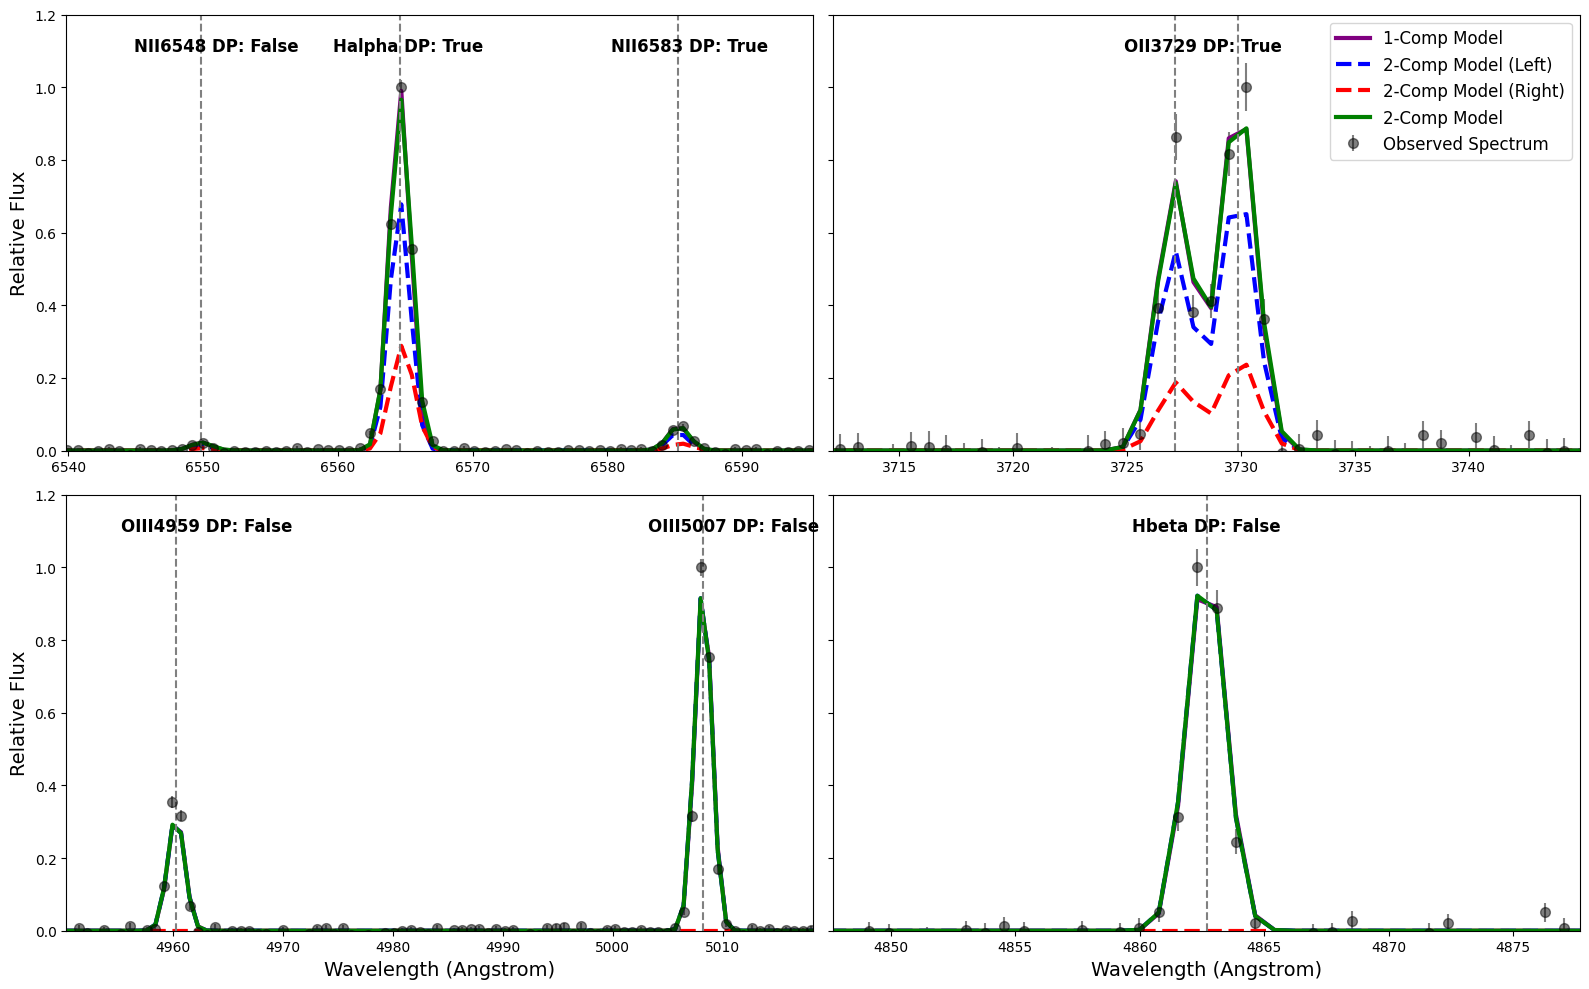

In [39]:
line_cols = ['OII3726', 'OII3729',
            'Hbeta',
            'OIII4959', 'OIII5007',
            'NII6548', 'Halpha', 'NII6583',
            'SII6716', 'SII6731']
lines = [*OII_rest, *Hbeta_rest, *OIII_rest, NII_rest[0], *Halpha_rest, NII_rest[1], *SII_rest]

# plt.figure(figsize=(12,6))

fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
plt.subplots_adjust(wspace=-0.8)
axes = axes.flatten()

for i, ax in enumerate(axes):

    
    # plt.plot(lam, emission, label='Emission Line Only', color='orange', alpha=0.7)
    # plt.plot(lam, 3*sigma, label=r'3$\sigma$ Limit', color='red', linestyle='--')
    # plt.text(6550, 10, 'test', rotation=90, color='gray', fontsize=8)
    # ax.set_xlabel('Wavelength (Angstrom)')
    # ax.set_ylabel('Flux')
    if i == 0:
        ax.set_xlim([NII_rest[0]-10, NII_rest[1]+10])
        ax.set_ylabel('Relative Flux', fontsize=14)
    elif i == 1:
        ax.set_xlim([OII_rest[0]-15, OII_rest[1]+15])
    elif i == 2:
        ax.set_xlim([OIII_rest[0]-10, OIII_rest[1]+10])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)
        ax.set_ylabel('Relative Flux', fontsize=14)
    elif i == 3:
        ax.set_xlim([Hbeta_rest[0]-15, Hbeta_rest[0]+15])
        ax.set_xlabel('Wavelength (Angstrom)', fontsize=14)

    v_max = np.max(flux[(lam>ax.get_xlim()[0]) & (lam<ax.get_xlim()[1])])
    ax.set_ylim(bottom=0, top=1.2)

    ax.errorbar(lam, flux/v_max, yerr=sigma/v_max, label='Observed Spectrum', fmt='o', color='k', markersize=7, alpha=0.5)
    ax.plot(lam, test_1comp/v_max, label='1-Comp Model', linewidth=3, color='purple')
    ax.plot(lam, test_2comp_l/v_max, label='2-Comp Model (Left)', linestyle='--', linewidth=3, color='blue')
    ax.plot(lam, test_2comp_r/v_max, label='2-Comp Model (Right)', linestyle='--', linewidth=3, color='red')
    ax.plot(lam, test_2comp/v_max, label='2-Comp Model', linewidth=3, color='green')

    
    for i, line in enumerate(lines):

        if line < ax.get_xlim()[0] or line > ax.get_xlim()[1]:
            continue
        else:
            ax.axvline(x=line, color='gray', linestyle='--')
            if i != 0:
                line_label = f'{line_cols[i]} DP: {example_df[line_cols[i]+'_DP']}'
                if i != 2:
                    ax.text(line-5, 1.1, line_label, color='k', fontsize=12, weight='bold')
                else:
                    ax.text(line-3, 1.1, line_label, color='k', fontsize=12, weight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()

plt.show()


In [40]:
print(image_link(example_df['RA'], example_df['DEC'], plot=True, save_image=False, fname=f"./images/{example_df['TARGETID']}_image.jpg"))
print(spectrum_link(example_df['TARGETID']))

https://www.legacysurvey.org/viewer?ra=198.87466430664062&dec=1.3493614196777344&layer=hsc-dr3&zoom=14
https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627818262334340
